绘制窗口

In [ ]:
python main.py --plot --device cuda --N 1500  --csv circle_RF_r100_z600_drf350.csv --config circle.json --color_mode y_pos --smooth-axes z,x

In [ ]:
存储traj数据

In [ ]:
python main.py --N 500 --alpha 0.2 --color_mode isotope --save_fig_dir --save_rv_traj_dir --save_times_us 50,100,200,300,400,500,600,700,800,900,1000 --time 1010 --isotope Ba138

绘制电势的空间分布与拟合(1D)

In [ ]:
python field_visualize.py --offset --vary z,x --x_range=-100,100 --y_range=-50,50 --fit 4 --csv circle_RF_r100_z600_drf350.csv --config circle.json --n_pts 500,500 --smooth-axes z,x

绘制电势的空间分布(2D)

In [ ]:
python field_visualize.py --offset --vary z,x --y_range=-50,50 --fit 4 --mode 3d

测试cpu与cuda各自和理论值的偏差(tests/test_cpu_cuda_error_accumulation.py)

In [ ]:
python tests/test_cpu_cuda_error_accumulation.py --time 

测试cpu与cuda之间的偏差(tests/test_cpu_cuda_trajectory_distance.py)

In [ ]:
python tests/test_cpu_cuda_trajectory_distance.py --time 100 --N 100 --out

In [ ]:
# 计算离子的平衡位置
python equilibrium/find_equilibrium.py --N 300 --fit-n-pts-x 100 --fit-n-pts-y 40 --fit-n-pts-z 200 --seed 9527 --color_mode y_pos --plot

In [ ]:
# 计算离子的mode vector
python -m equilibrium.find_equilibrium --N 300 --hessian-slice ::3 --plot-mode-vector 0 --plot-mode-vector-arrow-scale 0.5 --plot-mode-vector-out

In [ ]:
# 1000离子规模的求解
python -m equilibrium.find_equilibrium --N 1000 --config 1000.json --hessian-slice 1::3 --plot-mode-vector --plot-phonon-spectrum --z_range=-240,240 --plot --color_mode y_pos --x_range=-60,60 --plot-point-size 15

In [ ]:
# 10000离子规模的求解
python -m equilibrium.find_equilibrium --N 10000 --config 10000.json --hessian-slice 1::3 --plot-mode-vector --plot-phonon-spectrum --z_range=-600,600 --plot --color_mode y_pos --x_range=-100,100 --plot-point-size 8

In [1]:
# 阻尼计算脚本：γ = (4ℏk²/m)·sx/(1+s+4x²)（SI，单位 s⁻¹）；仿真无量纲 g = γ·dt
from __future__ import annotations

from pathlib import Path

from scipy.constants import hbar, pi

from FieldConfiguration.constants import init_from_config


def gamma_laser_cooling_si(k: float, m_kg: float, s: float, x: float) -> float:
    """
    图示公式：γ = (4ℏk²/m) · sx/(1+s+4x²)。

    Parameters
    ----------
    k : float
        波数大小 (m⁻¹)，常用 k = 2π/λ。
    m_kg : float
        离子质量 (kg)。
    s, x : float
        无量纲饱和参量与 detuning 相关变量（与公式中记号一致）。

    Returns
    -------
    float
        阻尼率 γ，单位 s⁻¹。
    """
    pref = 4.0 * hbar * k**2 / m_kg
    frac = (s * x) / (1.0 + s + 4.0 * x**2)
    return pref * frac


def g_normalized(gamma_si: float, dt: float) -> float:
    """
    用仿真时间单位 dt 将 γ 归一为程序中的无量纲阻尼强度 g（与 FieldSettings.g 一致）：

        g = γ_si · dt   （无量纲）
    """
    return gamma_si * dt


# --- 从 JSON 配置读取与本程序一致的 dt（由 RF 频率决定）---
_cfg, _raw = init_from_config(str(Path("FieldConfiguration/configs/default.json")))
_dt = _cfg.dt

# --- 示例：请按实验改 λ、s、x 与离子质量 ---
_m_ion = 2.239367e-25  # Ba135 参考质量 (kg)，与 FieldConfiguration/constants.py 中 m 一致
_lambda = 493e-9  # 例：波长 (m)
_k = 2 * pi / _lambda
_s, _x = 1.0, 2.0  # 例：饱和与 detuning 参数

_gamma = gamma_laser_cooling_si(_k, _m_ion, _s, _x)
_g = g_normalized(_gamma, _dt)

print(f"γ = {_gamma:.6e} s⁻¹")
print(f"dt = {_dt:.6e} s  (config RF ref = {_cfg.freq_RF} MHz)")
print(f"g = γ·dt = {_g:.6e}")

γ = 3.399650e+04 s⁻¹
dt = 9.022389e-09 s  (config RF ref = 35.28 MHz)
g = γ·dt = 3.067297e-04


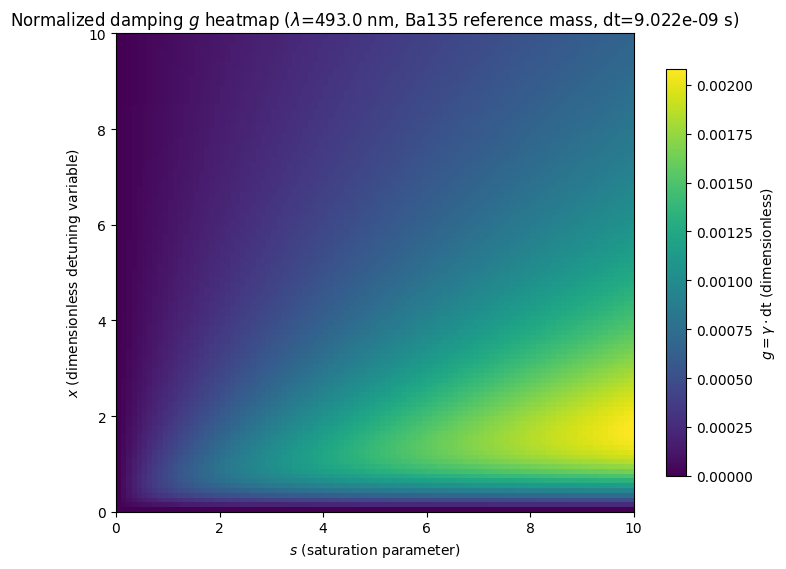

In [10]:
# Heatmap of dimensionless g = gamma·dt vs (s, x). Run the previous cell first for hbar, _k, _m_ion, _dt.
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

prefactor = 4.0 * hbar * _k**2 / _m_ion
s_vals = np.linspace(0, 10, 100)
x_vals = np.linspace(0, 10, 100)
S, X = np.meshgrid(s_vals, x_vals, indexing="ij")
gamma_grid = prefactor * (S * X) / (1.0 + S + 4.0 * X**2)
g_grid = gamma_grid * _dt

fig, ax = plt.subplots(figsize=(7.5, 5.8))
if np.nanmin(g_grid) < 0 < np.nanmax(g_grid):
    lim = float(np.nanmax(np.abs(g_grid)))
    norm = mcolors.TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)
    im = ax.imshow(
        g_grid.T,
        origin="lower",
        aspect="auto",
        extent=(s_vals[0], s_vals[-1], x_vals[0], x_vals[-1]),
        cmap="coolwarm",
        norm=norm,
    )
else:
    im = ax.imshow(
        g_grid.T,
        origin="lower",
        aspect="auto",
        extent=(s_vals[0], s_vals[-1], x_vals[0], x_vals[-1]),
        cmap="viridis",
    )

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label(r"$g = \gamma \cdot \mathrm{dt}$ (dimensionless)")
ax.set_xlabel(r"$s$ (saturation parameter)")
ax.set_ylabel(r"$x$ (dimensionless detuning variable)")
ax.set_title(
    rf"Normalized damping $g$ heatmap ($\lambda$={_lambda * 1e9:.1f} nm, Ba135 reference mass, dt={_dt:.3e} s)"
)
plt.tight_layout()
plt.show()